# Домашнее задание 10: Visual Language Models

Это домашнее задание направлено на изучение бимодальных моделей, интегрирующих визуальные и текстовые данные. В рамках данного задания мы поработаем с подвыборкой датасета COCO, где применим рассмотренные на лекциях модели для того чтобы найти bounding box'ы объектов на изображениях, а также семантические и инстанс сегментационные маски для них.

### План работы

1. **Подготовка датасета:** Создание класса для работы с данными.
2. **Генерация описаний с помощью BLIP:** Создание текстовых описаний изображений с использованием BLIP.
3. **Генерация тегов с помощью Recognize Anything Model (RAM):** Создание релевантных тегов для изображений.
4. **Определение bbox'ов с помощью Grounding DINO:** Использование сгенерированных описаний и тегов для детекции объектов через Grounding DINO.
5. **Автоматическая фильтрация несоответствий:** Реализация метода для автоматической фильтрации галлюционаций и ложных срабатываний с помощью CLIP.
6. **Сегментация с помощью Segment Anything Model (SAM):** Использование полученных в 4 задании bounding box'ов для создания сегментационных масок с помощью SAM.

In [1]:
# Устанавливаем нужные библиотеки
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install git+https://github.com/xinyu1205/recognize-anything.git
!pip install git+https://github.com/IDEA-Research/GroundingDINO.git
!pip install fairscale
!pip install -q "transformers==4.44.2"

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-22x9v1i4
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-22x9v1i4
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/xinyu1205/recognize-anything.git to /tmp/pip-req-build-vdcyj_si
  Running command git clone --filter=blob:none --quiet https://github.com/xinyu1205/recognize-anything.git /tmp/pip-req-build-vdcyj_si
  Resolved https://github.com/xinyu1205/recognize-anything.git to commit 7cb804a8609e9f4b1a50b7f31436d2df40bb9481
  Preparing metadata (setup.py) ... done
  Created wheel for ram: filename=ram-0.0.1-py3-none-any.whl size=128895 sha256=7bd8fd2941a1d2995cb1ae87e0e995e181bc670dbc17f6ecb8becf36e428db29
  Stored in directory: /tmp/pip-ephem-wheel-cache-t_salln9/wheels/fb/22/8f

In [4]:
# Импортируем библиотеки
import os
import json
import inspect
import csv
import ast
from collections import defaultdict
from typing import Any, Optional, Tuple

import cv2
import torch
import transformers
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from PIL import Image
from tqdm import tqdm
from albumentations.pytorch import ToTensorV2
from ram.models import ram_plus
from ram import inference_ram

# import groundingdino
# import groundingdino.datasets.transforms as T
# from groundingdino.util.inference import load_model, predict
from segment_anything import SamPredictor, sam_model_registry

### 2026.08.17 Data exploration

In [3]:
with open("/kaggle/input/datasets/andreykurdyubov/cv-hw10-grounded-sam/hw10-data/annotations/coco_categories.json", "r") as f:
    coco_cat = json.load(f)

with open("/kaggle/input/datasets/andreykurdyubov/cv-hw10-grounded-sam/hw10-data/annotations/student_annotations.json", "r") as f:
    anno = json.load(f)

print(anno.keys())

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])


In [ ]:
coco_cat

In [ ]:
anno["info"]

In [ ]:
anno["licenses"]

In [ ]:
anno["images"]

In [ ]:
anno["categories"]

In [ ]:
len(anno["images"])

In [ ]:
anno["annotations"][0]

In [ ]:
print([i["file_name"] for i in anno["images"]])

In [4]:
image_dir_stud = "/kaggle/input/datasets/andreykurdyubov/cv-hw10-grounded-sam/hw10-data/student"
image_dir_test = "/kaggle/input/datasets/andreykurdyubov/cv-hw10-grounded-sam/hw10-data/test"

file_names_stud = os.listdir(image_dir_stud)
file_names_test = os.listdir(image_dir_test)

print(file_names_stud)
print(file_names_test)

['000000007386.jpg', '000000449312.jpg', '000000200162.jpg', '000000093353.jpg', '000000166166.jpg']
['000000400794.jpg', '000000260105.jpg', '000000496954.jpg', '000000293390.jpg', '000000158660.jpg']


### Задание 1: Подготовка датасета

Реализуйте класс для работы с датасетом в формате COCO (Common Objects in Context):

1. Создайте класс `COCODataset` со следующими параметрами инициализации:
   - `image_dir` (str): путь к директории с изображениями
   - `category_mapping_file` (str): путь к файлу с маппингом категорий (JSON)
   - `annotation_file` (str): путь к файлу аннотаций в формате COCO (JSON), если есть

2. Класс должен реализовывать следующие методы:
   - `__len__` -> int: возвращает количество изображений в датасете
   
   - `__getitem__(idx: int) -> tuple[np.ndarray, dict]`: возвращает пару (изображение, аннотации)
     - изображение: numpy array размера (H, W, 3) в формате RGB
     - аннотации: словарь, содержащий:
       - 'image_id': int - ID изображения
       - 'boxes': np.ndarray с координатами bbox'ов в формате [x, y, width, height]
       - 'masks': np.ndarray бинарных масок
       - 'labels': list[str] с названиями лейблов
       - 'captions': list[str] с описаниями (может быть пустым)
   
   - `make_visualization(image: np.ndarray, annotations: dict) -> np.ndarray`:
     возвращает изображение с отрисованными:
     - bbox'ами с подписями лейблов
     - сегментационными масками

**Подсказки:**
- Используйте cv2 для работы с изображениями
- Если аннотаций нет, то используйте os.listdir(image_dir) для получения списка изображений и привяжите id к названию файла
- Остальные поля в возвращаемом словаре аннотаций должны быть пустыми
- Используйте детерминированные цвета на основе индекса объекта - [(i * 50) % 255, ((i * 50 + 85) % 255), ((i * 50 + 170) % 255)] (RGB)
- Для отрисовки текста используйте cv2.putText с белым цветом (255, 255, 255)

In [9]:
# QWEN
class COCODataset:
    def __init__(self, image_dir: str, category_mapping_file: str, annotation_file: Optional[str] = None):
        self.image_dir = image_dir
        self.category_mapping_file = category_mapping_file
        self.annotation_file = annotation_file
        
        # Load category mapping
        with open(category_mapping_file, 'r') as f:
            self.category_mapping = json.load(f)
            
        # Load annotations
        self.annotations = None
        self.img_to_anns = {}
        self.img_to_caps = {}
        
        if annotation_file is not None:
            with open(annotation_file, 'r') as f:
                self.annotations = json.load(f)
            
            # Группируем аннотации и капшены по image_id для быстрого доступа в __getitem__
            for ann in self.annotations.get('annotations', []):
                img_id = ann['image_id']
                
                # Проверяем, что это аннотация объекта (есть bbox или category_id)
                if 'bbox' in ann or 'category_id' in ann:
                    if img_id not in self.img_to_anns:
                        self.img_to_anns[img_id] = []
                    self.img_to_anns[img_id].append(ann)
                # Проверяем, что это caption
                elif 'caption' in ann:
                    if img_id not in self.img_to_caps:
                        self.img_to_caps[img_id] = []
                    self.img_to_caps[img_id].append(ann['caption'])
                    
            self.images_list = [img['file_name'] for img in self.annotations['images']]
        else:
            # Если аннотаций нет, берем список файлов из директории
            self.images_list = sorted(os.listdir(image_dir))

    def __len__(self) -> int:
        if self.annotations is not None:
            return len(self.annotations['images'])
        return len(self.images_list)
    
    def __getitem__(self, idx: int) -> Tuple[np.ndarray, dict]:
        if self.annotations is not None:
            img_info = self.annotations['images'][idx]
            img_id = img_info['id']
            file_name = img_info['file_name']
        else:
            file_name = self.images_list[idx]
            img_id = file_name  # Привязываем id к названию файла
            
        img_path = os.path.join(self.image_dir, file_name)
        
        # Читаем изображение и конвертируем из BGR в RGB
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Не удалось загрузить изображение: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        
        boxes, masks, captions, labels = [], [], [], []
        
        if self.annotations is not None:
            anns = self.img_to_anns.get(img_id, [])
            for ann in anns:
                # Bounding box в формате [x, y, width, height]
                boxes.append(ann['bbox'])
                
                # Получаем название категории (в JSON ключи всегда строки)
                cat_id = ann['category_id']
                label_name = self.category_mapping.get(str(cat_id), str(cat_id))
                labels.append(label_name)
                
                # Сегментационная маска
                if 'segmentation' in ann and isinstance(ann['segmentation'], list):
                    mask = self._polygon_to_mask(ann['segmentation'], h, w)
                    masks.append(mask)
                else:
                    masks.append(np.zeros((h, w), dtype=np.uint8))
                    
            # Капшены
            captions = self.img_to_caps.get(img_id, [])
    
        # Конвертируем списки в numpy массивы (обрабатываем случай пустых аннотаций)
        if len(boxes) > 0:
            boxes = np.array(boxes)  # float64 по умолчанию
            masks = np.array(masks, dtype=np.uint8)
        else:
            boxes = np.zeros((0, 4))  # float64 по умолчанию
            masks = np.zeros((0, h, w), dtype=np.uint8)
    
        annotations = {
            'image_id': img_id,
            'boxes': boxes,
            'masks': masks,
            'captions': captions,
            'labels': labels
        }
        
        return image, annotations
    
    def _polygon_to_mask(self, polygons: list[list[float]], height: int, width: int) -> np.ndarray:
        """
        Конвертирует полигоны в бинарную маску
        """
        mask = np.zeros((height, width), dtype=np.uint8)
        for polygon in polygons:
            if len(polygon) < 6:  # Нужно минимум 3 точки (6 координат)
                continue
            polygon = np.array(polygon).reshape(-1, 2)
            polygon = polygon.astype(np.int32)
            cv2.fillPoly(mask, [polygon], 1)
        return mask
    
    def make_visualization(self, image: np.ndarray, annotations: dict) -> np.ndarray:
        vis_image = image.copy()
        
        boxes = annotations['boxes']
        masks = annotations['masks']
        labels = annotations['labels']
        num_objects = len(labels)
        
        # 1. Отрисовка сегментационных масок
        if num_objects > 0 and len(masks) > 0:
            mask_overlay = np.zeros_like(image)
            for i in range(num_objects):
                # Детерминированный цвет в RGB
                r = (i * 50) % 255
                g = ((i * 50 + 85) % 255)
                b = ((i * 50 + 170) % 255)
                # OpenCV использует BGR
                color_bgr = (b, g, r) 
                
                mask = masks[i]
                # Закрашиваем пиксели маски выбранным цветом
                mask_overlay[mask == 1] = color_bgr
            
            # Смешиваем оригинальное изображение и оверлей масок
            vis_image = cv2.addWeighted(vis_image, 0.7, mask_overlay, 0.3, 0)
        
        # 2. Отрисовка bounding boxes и лейблов
        if num_objects > 0 and len(boxes) > 0:
            for i in range(num_objects):
                r = (i * 50) % 255
                g = ((i * 50 + 85) % 255)
                b = ((i * 50 + 170) % 255)
                color_bgr = (b, g, r)
                
                x, y, bw, bh = boxes[i]
                x, y, bw, bh = int(x), int(y), int(bw), int(bh)
                
                # Рисуем прямоугольник
                cv2.rectangle(vis_image, (x, y), (x + bw, y + bh), color_bgr, 2)
                
                # Рисуем текст (лейбл)
                label = labels[i]
                # Позиционируем текст чуть выше левого верхнего угла бокса
                text_y = max(15, y - 5) 
                cv2.putText(vis_image, label, (x, text_y), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
                
        return vis_image

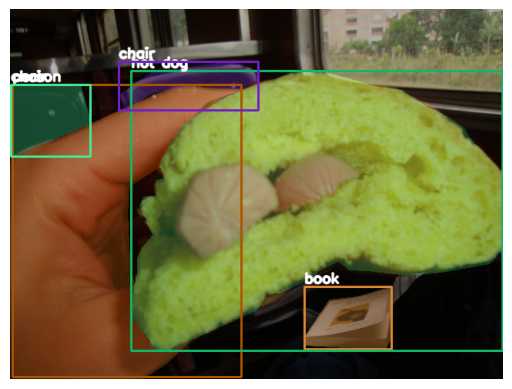

In [10]:
src_dir = "/kaggle/input/datasets/andreykurdyubov/cv-hw10-grounded-sam"
image_dir = os.path.join(src_dir, 'hw10-data', 'student')
test_dir = os.path.join(src_dir, 'hw10-data', 'test')
annotation_file = os.path.join(src_dir, 'hw10-data', 'annotations', 'student_annotations.json')
category_mapping_file = os.path.join(src_dir, 'hw10-data', 'annotations', 'coco_categories.json')

dataset = COCODataset(image_dir, category_mapping_file, annotation_file)
sample, annotations = dataset[0]
sample_vis = dataset.make_visualization(sample, annotations)

plt.imshow(sample_vis)
plt.axis('off')
plt.show()

In [ ]:
# Решение автора
class COCODataset:
    def __init__(self, image_dir: str, category_mapping_file: str, annotation_file: Optional[str] = None):
        self.image_dir = image_dir
        self.category_mapping_file = category_mapping_file
        self.annotation_file = annotation_file
        
        self.annotations = None
        if annotation_file is not None:
            with open(annotation_file, 'r') as f:
                self.annotations = json.load(f)
            
            self.image_to_anns = defaultdict(list)
            for ann in self.annotations['annotations']:
                img_id = ann['image_id']
                self.image_to_anns[img_id].append(ann)
            
            self.image_info = {img['id']: img for img in self.annotations['images']}
        else:
            self.images_list = os.listdir(image_dir)

        with open(category_mapping_file, 'r') as f:
            self.category_mapping = json.load(f)
        
    def __len__(self) -> int:
        """Return the total number of images in the dataset."""
        return len(self.annotations['images'])
    
    def __getitem__(self, idx: int) -> tuple[np.ndarray, dict]:
        if self.annotations is not None:
            img_info = self.annotations['images'][idx]
            img_id = img_info['id']
        else:
            img_info = {'file_name': self.images_list[idx]}
            img_id = self.images_list[idx]
        
        img_path = os.path.join(self.image_dir, img_info['file_name'])
        image = cv2.imread(img_path)
        if image is None:
            raise ValueError(f"Failed to load image: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        boxes, labels, masks, captions = [], [], [], []
        
        if self.annotations is not None:
            anns = self.image_to_anns.get(img_id, [])

            for ann in anns:
                if 'bbox' in ann:
                    boxes.append(ann['bbox'])
                    labels.append(self.category_mapping[str(ann['category_id'])])
                
                if 'segmentation' in ann:
                    mask = self._polygon_to_mask(
                        ann['segmentation'],
                        img_info['height'],
                        img_info['width']
                    )
                    masks.append(mask)
                
                if 'caption' in ann:
                    captions.append(ann['caption'])

        annotations = {
            'image_id': img_id,
            'boxes': np.array(boxes),
            'masks': np.array(masks),
            'captions': captions,
            'labels': labels
            }
        
        return image, annotations
    
    def _polygon_to_mask(self, polygons: list[list[float]], height: int, width: int) -> np.ndarray:
        mask = np.zeros((height, width), dtype=np.uint8)
            
        for polygon in polygons:
            points = np.array(polygon).reshape(-1, 2)
            points = points.astype(np.int32)
            cv2.fillPoly(mask, [points], 1)
                
        return mask
    
    def make_visualization(self, image: np.ndarray, annotations: dict) -> np.ndarray:
        vis_image = image.copy()
        
        if len(annotations['masks']) > 0:
            mask_overlay = np.zeros_like(image)
            for i, mask in enumerate(annotations['masks']):
                color = np.array([(i * 50) % 255, ((i * 50 + 85) % 255), ((i * 50 + 170) % 255)])
                mask_overlay[mask > 0] = color
            vis_image = cv2.addWeighted(vis_image, 0.7, mask_overlay, 0.3, 0)
        
        for i, (box, label) in enumerate(zip(annotations['boxes'], annotations['labels'])):
            x, y, w, h = map(int, box)
            color = tuple([(i * 50) % 255, ((i * 50 + 85) % 255), ((i * 50 + 170) % 255)])
            
            cv2.rectangle(vis_image, (x, y), (x + w, y + h), color, 2)
            
            (label_w, label_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(vis_image, (x, y - label_h - 5), (x + label_w, y), color, -1)
            cv2.putText(vis_image, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        return vis_image

In [ ]:
src_dir = "/kaggle/input/datasets/andreykurdyubov/cv-hw10-grounded-sam"
image_dir = os.path.join(src_dir, 'hw10-data', 'student')
test_dir = os.path.join(src_dir, 'hw10-data', 'test')
annotation_file = os.path.join(src_dir, 'hw10-data', 'annotations', 'student_annotations.json')
category_mapping_file = os.path.join(src_dir, 'hw10-data', 'annotations', 'coco_categories.json')

dataset = COCODataset(image_dir, category_mapping_file, annotation_file)
sample, annotations = dataset[0]
sample_vis = dataset.make_visualization(sample, annotations)

plt.imshow(sample_vis)
plt.axis('off')
plt.show()

### Задание 2: Генерация описаний с помощью BLIP


В данном задании необходимо реализовать класс `BlipProcessor`, который будет использовать модель BLIP ("Salesforce/blip-image-captioning-base") из библиотеки transformers для генерации текстовых описаний изображений.

Создайте класс `BlipProcessor` со следующей функциональностью:
   - Инициализация модели BLIP и его препроцессинга для генерации описаний изображений
   - Метод `process_image`, который принимает:
     - изображение
     - id изобаржения
   - Реализация механизма кэширования результатов на основе image_id

**Ожидаемый результат**:
- Класс должен корректно генерировать текстовые описания для входных изображений
- При повторной обработке одного и того же изображения (с тем же image_id) результат должен браться из кэша
- Описания должны генерироваться на английском языке

In [ ]:
#QWEN
from transformers import BlipProcessor as HFBlipProcessor, BlipForConditionalGeneration

class BlipProcessor:
    def __init__(self, device: str = "cpu"):
        self.device = torch.device(device)
        self.processor = transformers.BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
        self.model = transformers.BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(self.device)
        self.cache = {}
        
    def process_image(self, image: np.ndarray, image_id: Optional[int] = None) -> str:
        # Корректная проверка (работает для image_id == 0)
        if image_id is not None and image_id in self.cache:
            return self.cache[image_id]
            
        # Processor сам обрабатывает numpy array
        inputs = self.processor(images=image, return_tensors="pt")
        
        # Генерация с ограничением длины
        with torch.no_grad():
            output = self.model.generate(
                pixel_values=inputs['pixel_values'].to(self.device),
                max_new_tokens=50
            )
            
        caption = self.processor.decode(output[0], skip_special_tokens=True)
        
        # Корректное сохранение в кеш
        if image_id is not None:
            self.cache[image_id] = caption
            
        return caption

In [ ]:
blip_processor = BlipProcessor("cpu")
image, annotations = dataset[0]
caption = blip_processor.process_image(image, annotations['image_id'])
print(caption)

In [ ]:
test_dataset = COCODataset(image_dir=test_dir,
                           category_mapping_file=category_mapping_file,
                           annotation_file=None)

test_captions = []
for sample in tqdm(test_dataset):
    image, annotations = sample
    caption = blip_processor.process_image(image)
    test_captions.append((annotations['image_id'], caption))

with open('test_captions_qwen.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['image_id', 'caption'])
    writer.writerows(test_captions)

In [ ]:
# Решение автора
class BlipProcessor:
    def __init__(self, device: str = "cpu"):
        self.device = torch.device(device)
        self.processor = transformers.BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
        self.model = transformers.BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(self.device)
        self.cache = {}
        
    def process_image(self, image: np.ndarray, image_id: Optional[int] = None) -> str:
        # Check cache first
        if image_id and image_id in self.cache:
            return self.cache[image_id]
            
        # Process image if not in cache
        inputs = self.processor(images=image, return_tensors="pt")
        
        # Generate caption
        with torch.no_grad():
            output = self.model.generate(pixel_values=inputs['pixel_values'].to(self.device), max_new_tokens=50)
            
        # Decode the generated caption
        caption = self.processor.decode(output[0], skip_special_tokens=True)
        
        # Cache the result if image_id is available
        if image_id:
            self.cache[image_id] = caption
            
        return caption

В качестве ответа загрузите полученный csv в LMS.

### Задание 3: Генерация тегов с помощью Recognize Anything Model (RAM)


Вам необходимо реализовать класс `RamProcessor`, который будет использовать модель Recognize Anything Model++ (RAM++) для генерации тегов изображений. Скачайте веса с [ссылки](https://huggingface.co/xinyu1205/recognize-anything-plus-model/blob/main/ram_plus_swin_large_14m.pth) в [официальном репозитории](https://github.com/xinyu1205/recognize-anything/) и поместите в папку 'pretrained'.

1. Создайте класс `RamProcessor`, который должен:
   - Инициализировать модель RAM++, а также препроцессинг к нему (`image_size` берите 384)
   - Иметь метод `process_image`, который принимает изображение и опционально идентификатор изображения (image_id)
   - Возвращать список тегов, сгенерированных для изображения

2. Реализуйте механизм кэширования:
   - Если при вызове метода `process_image` был предоставлен идентификатор изображения (image_id), класс должен сохранить сгенерированные теги в кэше
   - При повторном запросе с тем же идентификатором изображения теги должны браться из кэша без повторной обработки изображения

In [ ]:
# QWEN
class RamProcessor:
    def __init__(self, categories: list[str], device: str = "cpu"):
        self.device = torch.device(device)
        
        # Препроцессинг с использованием albumentations
        self.transforms = A.Compose([
            A.Resize(384, 384, interpolation=cv2.INTER_LINEAR),
            A.Normalize(),
            ToTensorV2()
        ])
        
        # Загрузка модели RAM++
        pretrained_path = '/kaggle/input/datasets/anhnguyen12345/ram-weight/ram_plus_swin_large_14m.pth'
              
        self.model = ram_plus(
            pretrained=pretrained_path,
            image_size=384,
            vit='swin_l'
        )
        self.model.eval()
        self.model.to(device)
        
        self.cache = {}

    def process_image(self, image: np.ndarray, image_id: Optional[int] = None) -> list[str]:
        # Проверка кеша
        if image_id is not None and image_id in self.cache:
            return self.cache[image_id]

        # Препроцессинг изображения
        inputs = self.transforms(image=image)['image'].unsqueeze(0).to(self.device)
        
        # Инференс модели
        tags, _ = inference_ram(inputs, self.model)

        # Сохранение в кеш
        if image_id is not None:
            self.cache[image_id] = tags

        return tags

In [ ]:
categories = list(dataset.category_mapping.values())

ram_processor = RamProcessor(categories, "cpu")
image, annotations = dataset[0]
tags = ram_processor.process_image(image, annotations['image_id'])
print(tags)

In [ ]:
test_dataset = COCODataset(image_dir=test_dir,
                           category_mapping_file=category_mapping_file,
                           annotation_file=None)

test_tags = []
for sample in tqdm(test_dataset):
    image, annotations = sample
    tags = ram_processor.process_image(image)
    test_tags.append((annotations['image_id'], tags))

with open('test_tags_qwen_5.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['image_id', 'tags'])
    writer.writerows(test_tags)

In [ ]:
# Решение автора
class RamProcessor:
    def __init__(self, device: str = "cpu"):
        self.device = torch.device(device)
        self.transforms = A.Compose([
            A.Resize(384, 384, interpolation=cv2.INTER_LINEAR),
            A.Normalize(),
            ToTensorV2()
        ])
        self.model = ram_plus(pretrained='pretrained/ram_plus_swin_large_14m.pth',\
                              image_size=384,
                              vit='swin_l')
        self.model.eval()
        self.model.to(device)

        self.cache = {}

    def process_image(self, image: np.ndarray, image_id: Optional[int] = None) -> list[str]:
        if image_id is not None and image_id in self.cache:
            return self.cache[image_id]

        inputs = self.transforms(image=image)['image'].unsqueeze(0).to(self.device)
        tags, _ = inference_ram(inputs, self.model)

        if image_id is not None:
            self.cache[image_id] = tags

        return tags

Загрузите полученный csv в LMS.

### Задание 4: Определение bbox'ов с помощью Grounding DINO

Реализуем класс `DinoProcessor`, который будет использовать Grounding DINO для детекции объектов на основе текстового промпта (caption/tags). Скачайте [веса](https://huggingface.co/ShilongLiu/GroundingDINO/resolve/main/groundingdino_swinb_cogcoor.pth) с [официального репозитория](https://github.com/IDEA-Research/GroundingDINO) и поместите и в папку 'pretrained'.

С Grounding DINO вы уже поработали на практике, сейчас лишь требуется воспроизвести тоже самое в виде класса, метод `process_image` должен возвращать bbox'ы (в формате x, y, w, h, где x и y - координаты левого верхнего угла), логиты и классы. Не забудьте имплементировать кэширование как в предыдущих заданиях.

**Подсказка**: `load_image` принимает путь к файлу, метод `process_image` работает с `np.ndarray`.

**Подсказка 2**: сами решите какой текстовый промпт лучше подавать в модель - caption от BLIP или теги от RAM - а также *как* его лучше подавать в модель. Посмотрите еще раз практику, если потребуется.

In [ ]:
# QWEN
import importlib.util

class DinoProcessor:
    def __init__(self, device: str = 'cpu'):
        self.device = torch.device(device)
        self.cache = {}
        
        # Динамически находим путь к конфигу внутри установленной библиотеки
        spec = importlib.util.find_spec("groundingdino")
        if spec is not None:
            config_path = os.path.join(os.path.dirname(spec.origin), "config", "GroundingDINO_SwinT_OGC.py")
        else:
            config_path = "groundingdino/config/GroundingDINO_SwinT_OGC.py"
            
        checkpoint_path = "pretrained/groundingdino_swint_ogc.pth"
        
        if not os.path.exists(checkpoint_path):
            os.makedirs("pretrained", exist_ok=True)
            print("Скачивание весов Grounding DINO...")
            torch.hub.download_url_to_file(
                "https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth",
                checkpoint_path
            )
            print("Веса успешно загружены.")
        else:
            print("Веса Grounding DINO уже найдены.")
            
        print(f"Загрузка модели из конфига: {config_path}")
        self.model = load_model(config_path, checkpoint_path, device=self.device.type)
        self.model.eval()

    def process_image(self, image: np.ndarray, text_prompt: str, image_id: Optional[int] = None) -> Tuple[torch.Tensor, torch.Tensor, list[str]]:
        # ВАЖНО: Ключ кэша теперь - пара (image_id, text_prompt)
        cache_key = (image_id, text_prompt) if image_id is not None else None
        
        if cache_key is not None and cache_key in self.cache:
            return self.cache[cache_key]
        
        # Предобработка изображения
        image_pil = Image.fromarray(image)
        transform = T.Compose([
            T.RandomResize([800], max_size=1333),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
        image_tensor, _ = transform(image_pil, None)
        
        # Инференс модели
        boxes, logits, phrases = predict(
            model=self.model,
            image=image_tensor,
            caption=text_prompt,
            box_threshold=0.35,
            text_threshold=0.25,
            device=self.device.type
        )
        
        # Постобработка bbox'ов: перевод из [cx, cy, w, h] в [x, y, w, h] в абсолютных пикселях
        h, w, _ = image.shape
        boxes_xywh = []
        for box in boxes:
            cx, cy, bw, bh = box
            x = (cx - bw / 2) * w
            y = (cy - bh / 2) * h
            w_abs = bw * w
            h_abs = bh * h
            boxes_xywh.append([x.item(), y.item(), w_abs.item(), h_abs.item()])
        
        bboxes_tensor = torch.tensor(boxes_xywh)
        
        # Кэширование
        if cache_key is not None:
            self.cache[cache_key] = (bboxes_tensor, logits, phrases)
            
        return bboxes_tensor, logits, phrases

In [ ]:
ram_processor = RamProcessor("cpu")
sample, annotations = dataset[1]
tags = ram_processor.process_image(sample)
tags = " . ".join(tags.split(' | ')) + " . "

dino_processor = DinoProcessor("cpu")
bboxes, logits, labels = dino_processor.process_image(sample, tags)
annotations_pred = {
                   'image_id': annotations['image_id'],
                   'boxes': bboxes.detach().cpu().tolist(),
                   'labels': labels,
                   'masks': [],
                   'captions': []
                   }
sample_vis = dataset.make_visualization(sample, annotations_pred)

plt.imshow(sample_vis)
plt.axis('off')
plt.show()

По аналогии с предыдущими заданиями прогоните DinoProcessor на тестовых данных, сохраните в csv - оно должно иметь три колонки image_id, bbox, label (каждая детекция на новой строке).

In [ ]:
test_dataset = COCODataset(image_dir=test_dir,
                           category_mapping_file=category_mapping_file,
                           annotation_file=None)

results = []

print("Начинаем обработку тестового набора данных...")
for sample in tqdm(test_dataset, desc="Processing images"):
    image, annotations = sample
    image_id = annotations['image_id']
    
    # 1. Получаем теги от RAM
    ram_tags_str = ram_processor.process_image(image, image_id=image_id)
    
    # 2. Разбиваем строку тегов на список отдельных тегов
    # ram_tags_str имеет вид "tag1 | tag2 | tag3"
    ram_tags = [tag.strip() for tag in ram_tags_str.split('|') if tag.strip()]
    
    # 3. Для каждого тега отдельно вызываем DINO
    for tag in tqdm(ram_tags, desc=f"Tags for {image_id}", leave=False):
        # Передаем один тег как промпт
        # ВАЖНО: не добавляем " . " в конце, так как это один тег
        boxes, logits, labels = dino_processor.process_image(
            image, 
            tag, 
            image_id=image_id
        )
        
        # 4. Добавляем каждую детекцию как отдельную строку
        for i in range(len(boxes)):
            bbox = [float(coord) for coord in boxes[i]]
            # Используем json.dumps для сериализации bbox, как рекомендует поддержка
            results.append([image_id, json.dumps(bbox), tag])

# 5. Сохранение в CSV
output_filename = 'test_dino_predictions.csv'
with open(output_filename, 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['image_id', 'bbox', 'label'])
    writer.writerows(results)

print(f"✅ Готово! Результаты успешно сохранены в {output_filename}")
print(f"Всего сгенерировано детекций (строк в CSV): {len(results)}")

In [ ]:
# Решение автора
class DinoProcessor:
    def __init__(self, device: str = 'cpu'):
        self.device = device
        self.model = load_model(
            model_config_path=os.path.join(os.path.dirname(inspect.getfile(groundingdino)), 'config', 'GroundingDINO_SwinB_cfg.py'),
            model_checkpoint_path=os.path.join(os.getcwd(), 'pretrained', 'groundingdino_swinb_cogcoor.pth'),
            device = device)
        
        self.transform = T.Compose(
            [
                T.RandomResize([800], max_size=1333),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ]
        )
        self.cache = {}

    def process_image(self, image: np.ndarray, text_prompt: str, image_id: int = None) -> tuple[torch.Tensor, torch.Tensor, list[str]]:
        # Return cached result if available
        if image_id is not None and image_id in self.cache:
            return self.cache[image_id]
        
        H, W, _ = image.shape
        image, _ = self.transform(Image.fromarray(image, mode='RGB'), None)

        # Process the image using the model's detect method to get bounding boxes
        bboxes, logits, labels = predict( self.model,
                                          image,
                                          text_prompt,
                                          box_threshold=0.35,
                                          text_threshold=0.25,
                                          device=self.device)
        
        xc, yc, w, h = bboxes.unbind(-1)
        bboxes = torch.stack([xc - 0.5 * w, yc - 0.5 * h, w, h], dim=-1) * torch.tensor([W, H, W, H])

        # Cache the result if an image_id is provided
        if image_id is not None:
            self.cache[image_id] = (bboxes.detach().cpu().numpy(), logits.detach().cpu().numpy(), labels)

        return bboxes, logits, labels

# Задание 5: Фильтрация результатов с помощью CLIP

В данном задании вам необходимо реализовать класс `ClipProcessor`, который будет использовать модель CLIP из библиотеки transformers для фильтрации аннотаций изображений.

1. Реализуйте класс `ClipProcessor`, который должен инициализировать модель CLIP (используйте "openai/clip-vit-base-patch32") из библиотеки transformers.

2. Реализуйте метод `process_image`, который должен принимать изображение и словарь аннотаций, а возвращать отфильтрованный словарь аннотаций.

3. Метод `process_image` должен выполнять следующие задачи:
   - Фильтровать ббоксы, которые имеют высокий IoU друг с другом. Приоритет должен отдаваться ббоксам, которые имеют наивысшее соответствие между изображением и меткой (тегом).
   - Фильтровать некорректные пары "ббокс-метка", т.е. где вырезанная область изображения не соответствует метке.
   - Возвращает словарь `annotations` с отфильтрованными ббоксами.

4. Вы можете реализовывать дополнительные вспомогательные методы для необходимой функциональности - например, для вычисления IoU или кроппинга изображений.

In [ ]:
# QWEN
from torchvision.ops import box_iou
from transformers import CLIPModel, CLIPProcessor


class ClipProcessor:
    def __init__(self, device: str = "cpu"):
        self.device = torch.device(device)
        self.model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(self.device)
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.model.eval()

    def _compute_similarity(self, image_crop: Image.Image, label: str) -> float:
        """Вычисляет схожесть между изображением и текстом с помощью CLIP."""
        inputs = self.processor(
            text=[label], 
            images=image_crop, 
            return_tensors="pt", 
            padding=True
        )
        
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = self.model(**inputs)
            logits_per_image = outputs.logits_per_image
            probs = logits_per_image.softmax(dim=1)
            
        return probs[0][0].item()

    def _crop_image(self, image: np.ndarray, bbox: list) -> Image.Image:
        """Вырезает область изображения по bounding box."""
        x, y, w, h = map(int, bbox)
        x1, y1, x2, y2 = x, y, x + w, y + h
        
        pil_image = Image.fromarray(image)
        crop = pil_image.crop((x1, y1, x2, y2))
        return crop

    def process_image(self, image: np.ndarray, annotations: dict[str, Any], 
                      iou_threshold: float = 0.5, 
                      similarity_threshold: float = 0.2) -> dict[str, Any]:
        
        if len(annotations['boxes']) == 0:
            return annotations
        
        boxes = annotations['boxes']
        labels = annotations['labels']
        
        # 1. Вычисляем схожесть для каждого бокса
        similarities = []
        for bbox, label in zip(boxes, labels):
            crop = self._crop_image(image, bbox)
            similarity = self._compute_similarity(crop, label)
            similarities.append(similarity)
        
        # 2. Фильтруем по порогу similarity
        valid_indices = [i for i, sim in enumerate(similarities) if sim >= similarity_threshold]
        
        if len(valid_indices) == 0:
            return {
                'image_id': annotations.get('image_id'),
                'boxes': [],
                'labels': [],
                'masks': [],
                'captions': []
            }
        
        # 3. Группируем боксы по label
        label_to_indices = defaultdict(list)
        for idx in valid_indices:
            label = labels[idx]
            label_to_indices[label].append(idx)
        
        # 4. Для каждой группы label применяем NMS
        final_indices = []
        
        for label, indices in label_to_indices.items():
            # Получаем боксы для этого label
            group_boxes = [boxes[i] for i in indices]
            group_sims = [similarities[i] for i in indices]
            
            # Конвертируем в [x1, y1, x2, y2]
            boxes_xyxy = []
            for bbox in group_boxes:
                x, y, w, h = bbox
                boxes_xyxy.append([x, y, x + w, y + h])
            
            boxes_tensor = torch.tensor(boxes_xyxy, dtype=torch.float32)
            
            # Сортируем по similarity (для NMS важен порядок)
            # Создаем список индексов, отсортированный по убыванию similarity
            sorted_indices = sorted(range(len(group_sims)), key=lambda i: group_sims[i], reverse=True)
            
            # Жадный NMS внутри группы
            kept_local = []
            for idx in sorted_indices:
                should_keep = True
                
                for kept_idx in kept_local:
                    iou = box_iou(
                        boxes_tensor[idx:idx+1], 
                        boxes_tensor[kept_idx:kept_idx+1]
                    ).item()
                    
                    if iou > iou_threshold:
                        should_keep = False
                        break
                
                if should_keep:
                    kept_local.append(idx)
            
            # Преобразуем локальные индексы в глобальные
            kept_global = [indices[i] for i in kept_local]
            final_indices.extend(kept_global)
        
        # 5. Формируем финальные аннотации
        final_boxes = [boxes[i] for i in final_indices]
        final_labels = [labels[i] for i in final_indices]
        
        final_masks = []
        if len(annotations.get('masks', [])) > 0:
            final_masks = [annotations['masks'][i] for i in final_indices]
        
        return {
            'image_id': annotations.get('image_id'),
            'boxes': final_boxes,
            'labels': final_labels,
            'masks': final_masks,
            'captions': annotations.get('captions', [])
        }

In [ ]:
clip_processor = ClipProcessor("cpu")
image, annotations = dataset[0]
annotations_filtered = clip_processor.process_image(image, annotations)

image_vis = dataset.make_visualization(image, annotations_filtered)

plt.imshow(image_vis)
plt.axis('off')
plt.show()

Отфильтруйте предсказания из предыдущего шага, загрузите csv в LMS.

In [ ]:
# Initialize the dictionary with empty lists for all required keys
test_annotations = defaultdict(dict)

# Read the CSV file using csv library
with open('/kaggle/input/datasets/andreykurdyubov/cv-hw10-grounded-sam/test_dino_predictions__.csv', 'r') as file:
    reader = csv.DictReader(file)
    
    for row in reader:
        image_id = row['image_id']
        
        # Добавляем image_id в словарь
        if 'image_id' not in test_annotations[image_id]:
            test_annotations[image_id]['image_id'] = image_id
        
        # The format is "[[x, y, h, w], ...]"
        bbox = ast.literal_eval(row['bbox'])
        if test_annotations[image_id].get('boxes', None) is None:
            test_annotations[image_id]['boxes'] = []
        test_annotations[image_id]['boxes'].append(bbox)
        
        # Parse labels
        label = row['label']
        if test_annotations[image_id].get('labels', None) is None:
            test_annotations[image_id]['labels'] = []
        test_annotations[image_id]['labels'].append(label)

In [ ]:
import json

clip_processor = ClipProcessor("cpu")
test_dataset = COCODataset(image_dir=test_dir,
                           category_mapping_file=category_mapping_file,
                           annotation_file=None)

test_detections = []
for sample in tqdm(test_dataset):
    image, annotations = sample
    image_id = annotations['image_id']
    
    # Фильтрация через CLIP
    filtered_annotations = clip_processor.process_image(
        image, 
        test_annotations[image_id], 
        iou_threshold=0.5,
        similarity_threshold=0.3  # Было 0.2
    )
    
    # Сохраняем каждую детекцию
    for bbox, label in zip(filtered_annotations['boxes'], filtered_annotations['labels']):
        # Используем json.dumps для корректного формата bbox
        test_detections.append((image_id, json.dumps(bbox), label))

# Сохранение в CSV
with open('test_detections_filtered_1.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['image_id', 'bbox', 'label'])
    writer.writerows(test_detections)

print(f"✅ Готово! Сохранено {len(test_detections)} детекций в test_detections_filtered.csv")

In [ ]:
# Решение автора
class ClipProcessor:
    def __init__(self, device: str = "cpu"):
        self.model = transformers.CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.processor = transformers.CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.device = torch.device(device)
        self.model.to(self.device)
        
    def calculate_iou(self, box1: list[int], box2: list[int]) -> float:
        # Calculate intersection area
        x_left = max(box1[0], box2[0])
        y_top = max(box1[1], box2[1])
        x_right = min(box1[0]+box1[2], box2[0]+box2[2])
        y_bottom = min(box1[1]+box1[3], box2[1]+box2[3])
        
        if x_right < x_left or y_bottom < y_top:
            return 0.0
        
        intersection_area = (x_right - x_left) * (y_bottom - y_top)
        
        # Calculate union area
        box1_area = box1[2] * box1[3]
        box2_area = box2[2] * box2[3]
        union_area = box1_area + box2_area - intersection_area
        
        return intersection_area / union_area if union_area > 0 else 0.0
    
    def compute_similarity_score(self, image_crop: np.ndarray, label: str) -> float:
        # Prepare inputs for the model
        inputs = self.processor(
            text=[label], 
            images=image_crop, 
            return_tensors="pt", 
            padding=True
        ).to(self.device)

        with torch.no_grad():
            # Get image and text features separately
            image_features = self.model.get_image_features(inputs.pixel_values)
            text_features = self.model.get_text_features(inputs.input_ids, 
                                                         attention_mask=inputs.attention_mask)
            
            # Normalize features
            image_features = image_features / image_features.norm(dim=1, keepdim=True)
            text_features = text_features / text_features.norm(dim=1, keepdim=True)
            
            # Calculate cosine similarity
            similarity = torch.matmul(image_features, text_features.T).item()
            
            # Ensure it's in 0-1 range for convenience
            similarity = (similarity + 1) / 2  # Convert from -1,1 to 0,1
        
        return similarity
    
    def crop_image(self, image: np.ndarray, bbox: list[int]) -> np.ndarray:
        x, y, w, h = bbox
        return image[y:y+h, x:x+w]
    
    def process_image(self, image: np.ndarray, annotations: dict[str, Any], 
                      iou_threshold: float = 0.5, 
                      similarity_threshold: float = 0.2) -> dict[str, Any]:
        boxes = annotations['boxes']
        labels = annotations['labels']
        
        if len(boxes) == 0:
            return annotations
        
        # Calculate similarity scores for all bbox-label pairs
        similarity_scores = []
        for box, label in zip(boxes, labels):
            box = [int(i) for i in box]
            cropped_img = self.crop_image(image, box)
            score = self.compute_similarity_score(cropped_img, label)
            similarity_scores.append(score)
        
        # Sort boxes, labels, and scores by similarity score (highest first)
        sorted_indices = np.argsort(similarity_scores)[::-1]
        sorted_boxes = [boxes[i] for i in sorted_indices]
        sorted_labels = [labels[i] for i in sorted_indices]
        sorted_scores = [similarity_scores[i] for i in sorted_indices]
        
        # Filter out boxes with high IoU and keep boxes with higher similarity scores
        kept_indices = []
        for i in range(len(sorted_boxes)):
            # Skip if similarity score is below threshold
            if sorted_scores[i] < similarity_threshold:
                continue
                
            # Check if current box has high IoU with any previously kept box
            keep = True
            for j in kept_indices:
                if self.calculate_iou(sorted_boxes[i], sorted_boxes[j]) > iou_threshold:
                    keep = False
                    break
            
            if keep:
                kept_indices.append(i)
        
        # Create filtered annotations
        filtered_boxes = [sorted_boxes[i] for i in kept_indices]
        filtered_labels = [sorted_labels[i] for i in kept_indices]

        annotations['boxes'] = filtered_boxes
        annotations['labels'] = filtered_labels
        
        return annotations

### Задание 6: Сегментация с помощью SAM

В этой задаче вам необходимо реализовать класс `SamProcessor`, который будет использовать модель SAM (Segment Anything Model) из библиотеки `segment_anything` для генерации сегментационных масок. Скачайте веса по [ссылке](https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth) из [официального репозитория](https://github.com/facebookresearch/segment-anything), возьмите "sam_vit_h_4b8939.pth" и поместите в папку 'pretrained'.

Создайте класс `SamProcessor`, который должен:
   - Инициализировать модель SAM из библиотеки `segment_anything`
   - Иметь метод `process_image`, который принимает:
     - Изображение (numpy массив в формате RGB с диапазоном значений 0-255)
     - Словарь аннотаций, содержащий ключ 'boxes' в формате xyhw (x, y, высота, ширина)
   - Метод `process_image` должен возвращать словарь аннотаций с добавленными ключами 'polygons' и 'masks', где под первым ключом хранятся сегментационные маски в формате полигонов (в 1D после flatten), а под вторым - в качестве бинарных масок.

In [11]:
def mask_to_polygon(mask: np.ndarray, eps: float = 5e-3) -> list[int]:
    mask = mask.astype(np.uint8)
    
    contours, _ = cv2.findContours(
        mask, 
        cv2.RETR_EXTERNAL, 
        cv2.CHAIN_APPROX_SIMPLE
    )
    
    polygons = []
    for contour in contours:
        perimeter = cv2.arcLength(contour, True)
        
        epsilon = eps * perimeter
        approx = cv2.approxPolyDP(contour, epsilon, True)
        
        polygon = approx.reshape(-1, 2)
        polygons.append(polygon)
    
    return polygons

In [12]:
from segment_anything import SamPredictor, sam_model_registry

class SamProcessor:
    def __init__(self, device: str = "cpu"):
        self.device = device
        
        # Путь к весам модели
        checkpoint_path = "/kaggle/input/datasets/seshurajup/segment-anything-models/sam_vit_h_4b8939.pth"
        
        # Скачиваем веса, если их нет
        if not os.path.exists(checkpoint_path):
            os.makedirs("pretrained", exist_ok=True)
            print("Скачивание весов SAM (vit_h)...")
            import urllib.request
            urllib.request.urlretrieve(
                "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth",
                checkpoint_path
            )
            print("Веса SAM успешно загружены.")
        else:
            print("Веса SAM уже найдены.")
        
        # Инициализация модели SAM (vit_h - самая точная)
        sam = sam_model_registry["vit_h"](checkpoint=checkpoint_path)
        sam.to(device=self.device)
        sam.eval()
        
        # Создаем предсказатель
        self.predictor = SamPredictor(sam)

    def process_image(self, image: np.ndarray, annotations: dict) -> dict:
        self.predictor.set_image(image)
        
        boxes = annotations['boxes']
        if isinstance(boxes, list):
            boxes_array = np.array(boxes)
        else:
            boxes_array = boxes
            
        if len(boxes_array) == 0:
            annotations['polygons'] = []
            return annotations
        
        x = boxes_array[:, 0]
        y = boxes_array[:, 1]
        w = boxes_array[:, 2]
        h = boxes_array[:, 3]
        boxes_xyxy = np.stack([x, y, x + w, y + h], axis=1)
        
        polygons = []
        
        for box in boxes_xyxy:
            masks, scores, logits = self.predictor.predict(
                point_coords=None,
                point_labels=None,
                box=box,
                multimask_output=False
            )
            
            mask = masks[0]
            polygon_list = mask_to_polygon(mask)
            
            if len(polygon_list) > 0:
                polygon_list.sort(key=lambda p: cv2.contourArea(p.reshape(-1, 1, 2)), reverse=True)
                polygons.append(polygon_list[0])  # numpy array (N, 2), НЕ flatten
            else:
                polygons.append(np.array([]).reshape(0, 2))
        
        annotations['polygons'] = polygons
        return annotations

Веса SAM уже найдены.


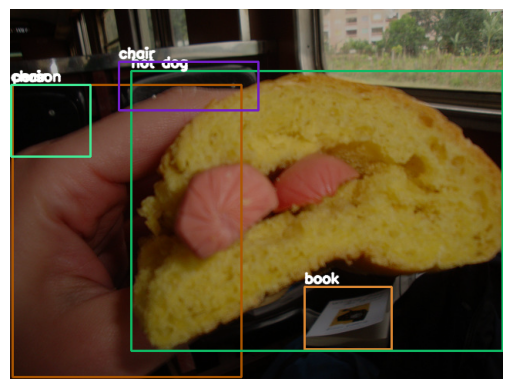

In [14]:
sam_processor = SamProcessor("cuda")
image, annotations = dataset[0]
annotations = sam_processor.process_image(image, annotations)
annotations['masks'] = [dataset._polygon_to_mask(polygons, *image.shape[:2]) for polygons in annotations['polygons']]
image_vis = dataset.make_visualization(image, annotations)

plt.imshow(image_vis)
plt.axis('off')
plt.show()

Прогоните его по тестовым данным, загрузите csv с парами image_id, mask, label на каждой строке в LMS. Маску сохраняйте как полигоны.

In [15]:
test_annotations = defaultdict(dict)
with open('/kaggle/input/datasets/andreykurdyubov/cv-hw10-grounded-sam/test_detections_filtered_1.csv', 'r') as file:
    reader = csv.DictReader(file)
    for row in reader:
        bbox = ast.literal_eval(row['bbox'])
        if test_annotations[row['image_id']].get('boxes', None) is None:
            test_annotations[row['image_id']]['boxes'] = []
        test_annotations[row['image_id']]['boxes'].append(bbox)
        
        label = row['label']
        if test_annotations[row['image_id']].get('labels', None) is None:
            test_annotations[row['image_id']]['labels'] = []
        test_annotations[row['image_id']]['labels'].append(label)

In [17]:
sam_processor = SamProcessor("cuda")
test_dataset = COCODataset(image_dir=test_dir,
                           category_mapping_file=category_mapping_file,
                           annotation_file=None)

test_masks = []
for sample in tqdm(test_dataset):
    image, annotations = sample
    image_id = annotations['image_id']

    annotations['boxes'] = test_annotations[image_id]['boxes']
    annotations['labels'] = test_annotations[image_id]['labels']

    annotations = sam_processor.process_image(image, annotations)
    for polygons, label in zip(annotations['polygons'], annotations['labels']):
        polygons_flat = polygons.flatten().tolist() if len(polygons) > 0 else []
        test_masks.append((image_id, polygons_flat, label))
        
with open('test_masks.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['image_id', 'mask', 'label'])
    for image_id, polygons, label in test_masks:
        writer.writerow([image_id, polygons, label])

Веса SAM уже найдены.


100%|██████████| 5/5 [00:11<00:00,  2.21s/it]


In [20]:
test_masks = []
for sample in tqdm(test_dataset):
    image, annotations = sample
    image_id = annotations['image_id']

    annotations['boxes'] = test_annotations[image_id]['boxes']
    annotations['labels'] = test_annotations[image_id]['labels']

    annotations = sam_processor.process_image(image, annotations)
    
    for polygons_list, label in zip(annotations['polygons'], annotations['labels']):
        # polygons_list - это список numpy массивов (N_i, 2) от mask_to_polygon
        if len(polygons_list) > 0:
            # Объединяем все полигоны в один массив (M, 2)
            all_points = np.vstack(polygons_list)
            # Flatten и tolist
            flat_polygons = all_points.flatten().tolist()
        else:
            flat_polygons = []
        
        # Сохраняем как список списков: [[x1, y1, x2, y2, ...]]
        test_masks.append((image_id, [flat_polygons], label))

with open('test_masks_1.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['image_id', 'mask', 'label'])
    for image_id, polygons, label in test_masks:
        writer.writerow([image_id, polygons, label])

100%|██████████| 5/5 [00:15<00:00,  3.10s/it]


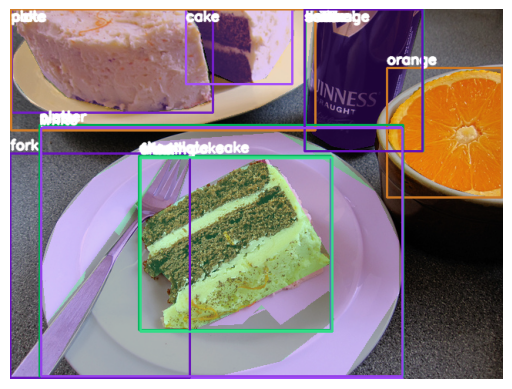

In [21]:
image, annotations = test_dataset[4]
image_id = annotations['image_id']
annotations = test_annotations[image_id]

masks = []
for id, polygons_nested, label in test_masks:
    if image_id == id:
        # Извлекаем flat список из вложенного списка
        flat_polygons = polygons_nested[0]
        
        # Проверяем, что полигон не пустой и имеет четное количество координат
        if len(flat_polygons) > 0 and len(flat_polygons) % 2 == 0:
            polygon = np.array(flat_polygons).reshape(-1, 2)
            mask = test_dataset._polygon_to_mask([polygon], *image.shape[:2])
            masks.append(mask)
        else:
            # Если полигон некорректный, создаем пустую маску
            masks.append(np.zeros(image.shape[:2], dtype=np.uint8))

annotations['masks'] = masks
image_vis = test_dataset.make_visualization(image, annotations)
plt.imshow(image_vis)
plt.axis('off')
plt.show()

In [ ]:
# Решение автора
class SamProcessor:
    def __init__(self, device: str = "cpu"):
        self.device = torch.device(device)
        self.model = sam_model_registry["vit_h"]("pretrained/sam_vit_h_4b8939.pth")
        self.model.to(self.device)
        self.predictor = SamPredictor(self.model)

    def process_image(self, image: np.ndarray, annotations: dict) -> dict:
        # Set the image for the SAM predictor
        self.predictor.set_image(image)
        
        # Convert boxes from xyhw format to xyxy format (expected by SAM)
        boxes = annotations.get('boxes', [])
        transformed_boxes = []
        
        for box in boxes:
            x, y, h, w = map(int, box)
            transformed_box = np.array([x, y, x + w, y + h])
            transformed_boxes.append(transformed_box)
        
        if transformed_boxes:
            transformed_boxes = np.array(transformed_boxes)
            
            # Generate masks for all boxes
            masks = []
            for box in transformed_boxes:
                mask, scores, _ = self.predictor.predict(
                    box=box,
                    multimask_output=True,  # Generate multiple mask options
                    return_logits=False
                )
                # Then select the best mask based on the confidence score
                best_mask_idx = np.argmax(scores)
                mask = mask[best_mask_idx]
                
                masks.append(mask)
            
            # Add masks to annotations
            annotations['polygons'] = [[polygon.flatten().tolist() for polygon in mask_to_polygon(mask)] for mask in masks]
            annotations['masks'] = masks
        else:
            # No boxes provided, return empty mask
            annotations['masks'] = []
        
        return annotations